###### Bog-fen Peatland
## January 2026 
### (C) Archontoula Valsamidou, Johan van de Koppel

### Royal Netherlands Institute for Sea Research (NIOZ), Department of Estuarine and Delta Systems, Yerseke, The Netherlands

#### This numerical model a fen wetland and a bog-fen complex peatland development. 

##### Valsamidou, A., van der Wal, D.,  Keller, G.K., Kleinhans, M.G.,  Rietkerk, M., van de Koppel, J. (2026). Hydrological feedbacks across space as drivers of complex peatland landscapes.
#### Whenever you use any part of this model code, please make sure to correctly refer to this manuscript and its authors.

### Model code

In [13]:
## Load Python packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, HTML, clear_output
import scipy.io
import time,os
%matplotlib inline
on = 1; off = 0

display(HTML("<style>.container { width:90% !important; }</style>"))

## Set the run number and model name
RUN = 1
ModelName = "Complex_Peat_RUN{}_012026_bog_fen".format(RUN)
print(ModelName)

from os import path
directory = ModelName
parent_dir = "./results/"

save_path = os.path.join(parent_dir, directory)
if not os. path. exists(save_path):
    os.mkdir(save_path)

import importlib
import plot_functions as PF  # Load plot_functions module
importlib.reload(PF)

Complex_Peat_RUN1_012026_bog_fen


<module 'plot_functions' from '/export/lv9/user/avalsamidou/reed_peat_2025/version_12/plot_functions.py'>

In [2]:
### GRAPH TEXT SIZE (for all figs) ###

# Set the default text font size
plt.rc('font', size=15)
# Set the axes title font size
plt.rc('axes', titlesize=15)
# Set the axes labels font size
plt.rc('axes', labelsize=15)
# Set the font size for x tick labels
plt.rc('xtick', labelsize=15)
# Set the font size for y tick labels
plt.rc('ytick', labelsize=15)
# Set the legend font size
plt.rc('legend', fontsize=14)
# Set the font size of the figure title
plt.rc('figure', titlesize=15)

In [3]:
## SENSITIVITY ANALYSIS: vary parameters (e.g. PARa) over a certain range
state_mean_us, state_mean_vs, state_mean_hs, state_mean_bs, state_mean_ss, state_mean_ds, state_mean_rs, state_mean_sos, state_mean_ts, state_mean_ns = [], [], [], [], [], [], [], [], [], [] # arrays for the mean values after every param value run
# Storage for the final elevation values:
final_elevation = []

# PARa_arr = np.array([...,...,...])     # To be defined, e.g. Oin_arr = np.array([0.0002, 0.0004, 0.0006, 0.0008, 0.001, 0.0012, 0.0014, 0.0016, 0.0018, 0.002]) --> see supplementary material for more details

## Start the actual simulations, while looping over the range of parameters PARa and PARb (OK.)

for SUBRUNa in range(1):             # for SUBRUNa in range(len(PARa_arr)):
    # PARa = PARa_arr[SUBRUNa]       # To be defined, e.g. Oin = Oin_arr[SUBRUNa]. Remember to disable PARa (in this example: Oin) below!

    ## Simulation parameters
    # Hydrodynamic parameters
    H0       = 0.02    # 0.02 [m] Imposed initial water layer thickness 
    g        = 9.8     # 9.8  [m/s^2] Gravitational acceleration constant
    nn       = 0.05    # 5e-2 [s m^(-1/3)] Gauckler-Manning friction coefficient (Chow, 1959); (Mariotti and Fagherazzi, 2012 JGR) => n=0.016
    rho      = 1000    # Water density [kg/m3]
    HCrit    = 0.001   # 1e-3 [m] Critical water layer thickness (is always retained) in wetting-drying algorithm
    slope    = 0.000   # 2e-5 [m/m] Subsediment plane bed slope
    DifU     = 0.05    # 1e-2 [m^2/s] Turbulent eddy viscosity
    Hin      = 0.000020 # 1e-5 [m] Rain

    # Vegetation roughness parameters - Chezy formulation
    nb       = 0.020   # 0.016 [s m^(-1/3)] Manning’s roughness coeff. for bare sediment
    nv       = 0.200   # 0.200 [s m^(-1/3)] Manning’s roughness coeff. for vegetated sediment
    Qv       = 0.5

    # Vegetation roughness parameters - Baptist equation
    Cb       = 20.0    # Chezy roughness of the bed (higher is smoother)
    Cd       = 2.0     # Chezy friction coefficient for maximal vegetation density
    Hv       = 0.5     # Shoot length
    kv       = 0.41    # Von Karman constant

    # Sedimentation parameters
    S_in     = 0.0005  # [m/s] Sediment input
    f        = 0.15    # The sediment input when plant biomass is zero
    Qp       = 0.5     # he value of plant biomass where sedimentation is half maximal
    Qs       = 0.006   # [-] Fraction of initial (homogeneous) water layer thickness at which sedimentation rate is (approximately) half maximal

    Es       = 7.0     # [s-1] "Background" erosion rate.
    po       = 0.9     # [-] Fraction by which sediment erosion is reduced if plants are at carrying capacity
    D0       = 0.05     # [m^2 s^-1] Sediment diffusivity in absence of plants
    pD       = 10.0     # [-] Degree to which sediment diffusivity is reduced if plants are at carrying capacity

    # Fen plant growth & erosion parameters
    rr       = 0.06    # [1/s] Growth rate plants
    kk       = 1.0     # [kg/m^2] Carrying capacity plants
    Qd       = 0.5     # [m] Value of water level where plant loss is (approximately) half max (higher Qd = lower overall loss rate)
    Ec       = 6.0     # [-] Conversion factor from sediment erosion to plant loss
    DifD     = 0.00001 # Lateral expansion of vegetation
    CompRD   = 1.3     # 

    # Spaghnum growth & erosion parameters
    rR       = 0.06    # 1/s] Growth rate Spaghnum
    kR       = 1.0     # [kg/m^2] Carrying capacity Spaghnum
    FR       = 1.0     # Friction imposed by spaghnum relative to higher plants
    QR       = 0.1     # [m] Value of water level where Spaghnum loss is (approximately) half max (higher Qd = lower overall loss rate)
    EcR      = 2.0     # [-] Conversion factor from sediment erosion to Spaghnum loss
    DifR     = 0.00005 # Lateral expansion of Spaghnum vegetation
    El       = 1.0     # [m] Elevation for which limitation is half
    Ep       = 4.0     # Power : Hill coefficient
    CompDR   = 1.25    # 

    # Organic matter parameters
    Oin      = 0.001   # Factor translating Spaghnum biomass to peat production
    Oout     = 0.001   # Organic matter degradation rate
    Eco      = 2.0     # Factor translating shear to peat erosion
    Omin     = 0.2     # Fraction of degradation remaining when o is high
    Ohalf    = 0.5     # [m] Value of o where degradation is half max
    DifO     = 0.001   # Lateral dispersion of organic matter
        
    FrictionType = 'Baptist'  # Manning or Baptist
        
    ## Time settings  
    BuildFen = off

    if BuildFen == on:
        EndTime   = 10000   # total time
        dT        = 0.010   # time step
    else:
        EndTime   = 50000   # total time --> here shorter, complete complex run is 100000
        dT        = 0.025   # time step
    
    NumPlots  = 50          # Number of times the figure is updated --> here less, for complete complex run is 100
    frac      = 0.0001      # Fraction of the initial surface seeded with plants        

    ## Construct the spatial grid        
    # Number of nodes in each dimension of the simulated grid
    Grid_Width     = 1024      # Matrix width
    Grid_Height    = 1024      # Matrix height
    dX             = 0.1       # distance between nodes in X
    dY             = 0.1       # distance between nodes in Y
    # Physical dimensions of the landscape
    Length_X       = Grid_Width*dX   # Size of the domain in physical dimensions
    Length_Y       = Grid_Height*dY  # Size of the domain in physical dimensions    
    # Thread block size
    Block_Size_X   = 16      # 16
    Block_Size_Y   = 16      # 16
    print('Physical dimensions [L]: %1.1f x %1.1f' % (Length_X, Length_Y))

    # Derived simulation parameters 
    Block_Number_X =  Grid_Width / Block_Size_X    
    Block_Number_Y =  Grid_Height / Block_Size_Y     

    if (Block_Number_X%1>0) or (Block_Number_Y%1>0):
        raise RuntimeError("Block number not an whole number. Blocks don't fit.")

    dX = Length_X/Grid_Width    # space step
    dY = Length_Y/Grid_Height   # space step
    print('Grid dimensions: %d x %d, spatial step size %1.1f x %1.1f' % (Grid_Width,Grid_Height, dX, dY))

    ## Compute uniform initial conditions
    h_homo = H0
    u_homo = np.sqrt(slope)*h_homo**(2.0/3.0)/nn # Balance between downslope acceleration and friction
    s_homo = 0.25; 
    
    X, Y = np.meshgrid(np.linspace(0,1,Grid_Width), np.linspace(0,1,Grid_Height))

    ## Initialize the variable arrays (numpy arrays) - ensure correct shape of arrays to be passed on to the GPU based on scenario --> fen or bog-fen
    def Matrix(X=0):
    # !!! For fen wetland run
#         if np.isscalar(X):
#             return np.full((Grid_Height, Grid_Width), X).ravel()
#         else:
#             return np.asarray(X).ravel()
    # !!! For bog-fen wetland run
        return np.zeros((Grid_Height,Grid_Width))+X
    def Random(Threshold):
    # !!! For fen wetland run
#         return (np.random.rand(Grid_Width*Grid_Height) < Threshold)
    # !!! For bog-fen wetland run
        return (np.random.rand(Grid_Width,Grid_Height) < Threshold)

    np.random.seed(12) # Good = 15
    
    if BuildFen == on:
        u = Matrix( u_homo )
        v = Matrix( 0.0 )
        h = Matrix( h_homo )
        b = Matrix( Y*slope*Length_X )
        s = Matrix( s_homo * Y/(0.05+Y) )
        d = Random( Threshold = frac ) * 2.0 + 0.0
        r = Matrix( 0.0 )
        so = Matrix( 0.0 )
    else:
        Data = np.load('Fen_%d_v12b.npz' % Grid_Width); 
        for varName in Data.files:
            exec(varName + " = Data[\"" + varName + "\"]")
        
        r = Random( Threshold = frac ) * 0.1 + 0.0
        r = Matrix( np.minimum(1,np.maximum(0.05/t,0))*(s>0.30)*Random( Threshold=1.0) )            
        d = Matrix( d-r )            
        so = Matrix( 0.0 )
            
        r = r.flatten()
        d = d.flatten()
        so = so.flatten()
            
        # Handle the flattening for all other arrays
        for varName in Data.files:
            if varName not in ['r', 'd', 'so']:  # Avoid flattening arrays that were already flattened
                globals()[varName] = globals()[varName].flatten()
        del Data

    # Used for storage purposes
    t = Matrix(0)
    t = t.flatten() 
        
    n = Matrix(0) 
    n = n.flatten()  

    ## Convert the numpy arrays (64-bit) to 32-bit floats in order for the "host" (GPU) to handle them faster
    u = u.astype(np.float32)
    v = v.astype(np.float32)
    h = h.astype(np.float32)
    b = b.astype(np.float32)
    s = s.astype(np.float32)
    d = d.astype(np.float32)
    r = r.astype(np.float32)
    so = so.astype(np.float32)

    import pyopencl as cl # Import openCL packages

    ## Define the device that is used

    DeviceNr = 0   # 0 = GPU; 1 = Intel; 2 = AMD 
    os.environ['PYOPENCL_COMPILER_OUTPUT'] = '1'
    platform = cl.get_platforms()
    Devices  = platform[0].get_devices()
    context  = cl.Context([Devices[DeviceNr]])
    queue    = cl.CommandQueue(context)

    print(" Activated Compute Device: %s\n" % Devices[DeviceNr].name)

    mf       = cl.mem_flags # Set memory flags

    ## The array is allocated on the GPU and the initial values are copied onto it

    u_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=u)
    v_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=v)
    h_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=h)
    b_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=b)
    s_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=s)
    d_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=d)
    r_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=r)
    so_gpu = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=so)

    ## Set up simulation parameters

    global_size = u.shape
    local_size  = (Block_Number_X*Block_Number_Y,)

    ## Setting up the parameters for the OpenCL kernel. Seperate with comma without spaces
        
    PassVars="H0,g,nn,HCrit,slope,DifU,Hin," + \
             "FR,Cb,Cd,Hv,kv,nb,nv,Qv," + \
             "S_in,f,Qp,Qs,Es,po,D0,pD," + \
             "rr,kk,Qd,Ec,DifD,CompRD," + \
             "rR,kR,QR,EcR,El,Ep,DifR,CompDR," + \
             "Oin,Oout,Eco,Omin,Ohalf,DifO," + \
             "dT,dX,dY,FrictionType," + \
             "Grid_Width,Grid_Height"

    PassVals=eval(PassVars)
    PassVars=PassVars.split(',')
    Params=""

    for ii in range(len(PassVals)):
        Params = Params+"#define " + PassVars[ii] + " " + str(PassVals[ii]) + " \n"

    ## OpenCL simulation kernel

    ComputeCode = """

    #define cl_max(A,B)	(A>B?A:B)
    #define cl_min(A,B)	(A<B?A:B)

    float difco(float d1, float d2, size_t column)
    {   
        float dm = (d1+d2)/2.0 ;
        float ds = exp(-pD*dm/(float)kk);
        return D0*ds;
    }

    float d2_dxy2_S(__global float* s, __global float* d) //, __global float* r
    {
        const float dx = dX;
        const float dy = dY;
            
        // Determine the position at which the current thread is computing
        const size_t current = get_global_id(0);            
        const size_t row     = (size_t)current/(size_t)Grid_Width; // Rounds down to integer, so row = 0 if current < Grid_Width, etc. 
        const size_t column  = (size_t)current%(size_t)Grid_Width;
        
        const size_t  left=row * Grid_Width + column-1;
        const size_t  right=row * Grid_Width + column+1;
        const size_t  top=(row-1) * Grid_Width + column;
        const size_t  bottom=(row+1) * Grid_Width + column;

        return difco(d[right]  ,d[current], column)/dx/dx * (s[right]   - s[current]) -
                   difco(d[current],d[left]   , column)/dx/dx * (s[current] - s[left]) +
                   difco(d[bottom] ,d[current], column)/dy/dy * (s[bottom]  - s[current]) -
                   difco(d[current],d[top]    , column)/dy/dy * (s[current] - s[top]);
    }
        
    float dOo_dx(__global float* b, __global float* s, __global float* so, __global float* h)
    {    
        // Determine the position at which the current thread is computing
        const float dx = dX;  // Forcing dX to become a float
        const size_t current = get_global_id(0);            
        const size_t row     = (size_t)current/(size_t)Grid_Width; // Rounds down to integer, so row = 0 if current < Grid_Width, etc. 
        const size_t column  = (size_t)current%(size_t)Grid_Width;
    
        // Determine the positions neigboring the current position
        const size_t left    =  row      * Grid_Width + column - 1;
        const size_t right   =  row      * Grid_Width + column + 1;
    
        return ( ( (h[right]+s[right]+b[right]+0.0*so[right])
                    - (h[left ]+s[left ]+b[left ]+0.0*so[left ]) ) /2.0/dx );
    }

    float dOo_dy(__global float* b, __global float* s, __global float* so, __global float* h)
    {
        // Determine the position at which the current thread is computing
        const float dy = dY;  // Forcing dY to become a float
        const size_t current = get_global_id(0);            
        const size_t row     = (size_t)current/(size_t)Grid_Width; // Rounds down to integer, so row = 0 if current < Grid_Width, etc. 
        const size_t column  = (size_t)current%(size_t)Grid_Width;
    
        // Determine the positions neigboring the current position
        const size_t top     = (row - 1) * Grid_Width + column    ;
        const size_t bottom  = (row + 1) * Grid_Width + column    ;
    
        return ( ( (h[bottom]+s[bottom]+b[bottom]+0.0*so[bottom])
                    - (h[top   ]+s[top   ]+b[top   ]+0.0*so[top   ]) ) /2.0/dy );
    }

    ////////////////////////////////////////////////////////////////////////////////
    // Simulation kernel
    ////////////////////////////////////////////////////////////////////////////////

    __kernel void SimulationKernel (__global float* u,
                                    __global float* v,
                                    __global float* h,
                                    __global float* b,
                                    __global float* s,
                                    __global float* d,
                                    __global float* r,
                                    __global float* so)
    {
        // A-priori variable definition

        float du, dv, dh, drh, ds, dd, dr, d_so;

        // Determining the position at which the current thread is computing

        const size_t current = get_global_id(0);
        const size_t row     = (size_t)current/(size_t)Grid_Width;
        const size_t column  = (size_t)current%(size_t)Grid_Width;

        // --- Determining frication, and computing change in flow ----------------------

        // The net speed of the water
        float uabs     = sqrt(u[current]*u[current]+v[current]*v[current]);

        // A make-shift wetting-drying algoritm
        h[current]     = cl_max(h[current],HCrit);
        float V_real   = d[current]+FR*r[current];

        #if FrictionType == Baptist
            // Computing the Chezy coefficient, using the baptist equation
            float Ct       = sqrt( (float)(1.0/(1.0/(Cb*Cb)+1.0/(2.0*g)*Cd*V_real*Hv)) )
                            + sqrt( (float)g)/(float)kv*log((float)cl_max(h[current]/Hv,1.0));
    
        #elif FrictionType == Manning
            // Computinh the Chezy coefficient, using Manning's bed roughness coefficient nn
            float nn = (float)nb + (float)(nv-nb)*(V_real/(float)cl_max(kk, kkR));
            float Ct = (float)(1.0 / (float)nn) * pow(h[current], (float)(1.0 / 6.0));
    
        #endif
            
        // Check if Ct is approximately zero (using a tolerance value)
        float tolerance = 1e-5; // Adjust this tolerance value as needed 1e-6
        float constantValue = 5.5; // Replace with your desired constant value
        if (fabs(Ct) < tolerance) 
        {// Ct is close to zero, replace it with a constant value
            Ct = constantValue;
        }
        float friction = g/(Ct*Ct)*uabs;
        
        if(row > 0 && row < Grid_Height-1 && column > 0 && column < Grid_Width-1)
        {
            // Change in water velocity u in the X direction
            du = - g*(dOo_dx(b,s,so,h))
                 - u[current]*d_dx(u)
                 - v[current]*d_dy(u)
                 - friction*u[current]/h[current]
                 + DifU*d2_dxy2(u);
        
            // Change in water velocity v in the Y direction
            dv = - g*dOo_dy(b,s,so,h)
                 - u[current]*d_dx(v)
                 - v[current]*d_dy(v)
                 - friction*v[current]/h[current]
                 + DifU*d2_dxy2(v);
        
            // Updating water flow
            u[current] = u[current] + du*dT;
            v[current] = v[current] + dv*dT;
        }

        // --- Handle Flow at the Boundaries ---------------------------------------
        else if(row==0) // Right boundaries
        {
            u[row * Grid_Width + column] = 2*u[1 * Grid_Width + Grid_Width] - u[2 * Grid_Width + Grid_Width];
            v[row * Grid_Width + column] = 2*v[1 * Grid_Width + Grid_Width] - v[2 * Grid_Width + Grid_Width];
        }
        else
        {
            ReflectingBoundaries(u,v);
        }

        // --- Remaining state variables are computed here -----------------------------

        if(row > 0 && row < Grid_Height-1 && column > 0 && column < Grid_Width-1)
        {
            float h_eff = h[current]-HCrit;
            float v_tot = d[current]+r[current];
            float shear = uabs*friction;
        
            // --- Continuity equation -------------------------------------------------
            dh = - d_uh_dx(u,h) - d_vh_dy(v,h);
            drh = Hin; // 
        
            // --- Sediment differential equation --------------------------------------
            ds = S_in * ( (f*Qp + v_tot)/(Qp + v_tot)) * h_eff / (Qs + h_eff)
                 - Es*(1-po*v_tot/max(kk,kR))*shear*s[current]
                 + d2_dxy2_S(s,d) ;
        
            // --- Algal differential equation -----------------------------------------
            float WaterLimitation_D = Qd/(Qd+h_eff) ;
            dd = rr*d[current]*(1 - d[current]/kk - CompRD*r[current]/kk) * WaterLimitation_D
                 - Ec*shear*d[current]
                 + DifD*d2_dxy2(d) ;

            // --- Spaghnum differential equation -----------------------------------------
            float WaterLimitation_R = QR/(QR+h_eff) ;
            float Elevation = b[current]+s[current]+so[current] ;
            float ElevationLimitation = pow(Elevation,(float)Ep)/(pow(Elevation,(float)Ep) + pow((float)El,(float)Ep));
        
            dr = rR*r[current]*(1 - r[current]/kR - CompDR*d[current]/kR) * WaterLimitation_R * ElevationLimitation 
                 - EcR*shear*r[current]
                 + DifR*d2_dxy2(r) ;       

            // --- Organic matter differential equation --------------------------------
            d_so = Oin*(r[current]) - Oout*so[current]
                   - Eco*shear*so[current]
                   + DifO*d2_dxy2(so) ;

            // --- Updating water level, sediment height, and algal density ------------
            float Phi = 1.0;    //0.25 // Morfological acceleration factor (1s = phi*1tide)

            h[current] = h[current] + dT*(dh+drh);
            s[current] = s[current] + dT*ds*Phi;
            d[current] = d[current] + dT*dd*Phi;
            r[current] = r[current] + dT*dr*Phi;
            so[current] = so[current] + dT*d_so*Phi;
        
        }

        // --- Handle Boundaries for h, s, and d ---------------------------------------
        else if(row==0) // Top boundary
        {
            NeumanBoundaries(h);   // No height gradient
            s[current] = 0;        // Fixed sediment height boundary
            d[current] = 0;
            r[current] = 0;
            so[current] = 0;
        }
        else if(row==Grid_Height-1) // Bottom boundary
        {
            NeumanBoundaries(h);   // No height gradient
            NeumanBoundaries(s);   // Fixed sediment height boundary
            d[current] = 1.0; 
            NeumanBoundaries(r);
            NeumanBoundaries(so);
        }
        else // Side boundary
        {
            NeumanBoundaries(h);   // No height gradient
            NeumanBoundaries(s);   // Zero flux in s
            d[current] = cl_max(((float)row/((float)row+50)),d[current]); 
            NeumanBoundaries(r);
            NeumanBoundaries(so);
        }

    } // End SimulationKernel        

"""

    ## Build code

    with open('HydroFunctions_iPy.cl', 'r') as myfile:
        SpatialFunctions = myfile.read()

    program = cl.Program(context, Params + SpatialFunctions + ComputeCode).build()

    ## Setting up a progress bar for the simulation

    from ipywidgets import FloatProgress
    from IPython.display import display
    # Define the total number of frames for the entire simulation
    Total_NumFrames = NumPlots
    print("Progress :");
    PB = FloatProgress(min=0, max=Total_NumFrames); display(PB) 
        
    # Definitions of arrays to save both phases
    us = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))
    vs = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))
    hs = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))
    bs = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))
    ss = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))
    ds = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))
    rs = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))
    sos = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))

    ts = np.zeros((Grid_Height, Grid_Width, Total_NumFrames)) # tau
    ns = np.zeros((Grid_Height, Grid_Width, Total_NumFrames)) # velocity
        
    CT = np.zeros((Grid_Height, Grid_Width, Total_NumFrames))

    ## Simulation loop 
    start_time = time.time() # Start a timer

    # Start the loop
    for count in range(Total_NumFrames):
        # Run the simulation
        for jj in range(int(EndTime/dT/Total_NumFrames)):
            program.SimulationKernel(queue, global_size, None, u_gpu, v_gpu, h_gpu, b_gpu, s_gpu, d_gpu, r_gpu, so_gpu)

        # Get the data from the GPU
        cl.enqueue_copy(queue, u, u_gpu)
        cl.enqueue_copy(queue, v, v_gpu)
        cl.enqueue_copy(queue, h, h_gpu)
        cl.enqueue_copy(queue, b, b_gpu)
        cl.enqueue_copy(queue, s, s_gpu)
        cl.enqueue_copy(queue, d, d_gpu)
        cl.enqueue_copy(queue, r, r_gpu)
        cl.enqueue_copy(queue, so, so_gpu)

        # Store the state of the system
        us[:, :, count] = u.reshape(Grid_Height, Grid_Width)
        vs[:, :, count] = v.reshape(Grid_Height, Grid_Width)
        hs[:, :, count] = h.reshape(Grid_Height, Grid_Width)
        bs[:, :, count] = b.reshape(Grid_Height, Grid_Width)
        ss[:, :, count] = s.reshape(Grid_Height, Grid_Width)
        ds[:, :, count] = d.reshape(Grid_Height, Grid_Width)
        rs[:, :, count] = r.reshape(Grid_Height, Grid_Width)
        sos[:, :, count] = so.reshape(Grid_Height, Grid_Width)

        # The net flow speed an any location is computed
        ns[:,:,count] = np.sqrt(us[:,:,count]**2 + vs[:,:,count]**2)
        # The bottom shear stess is stored
        CT[:,:,count] = np.sqrt( (1.0/(1.0/(Cb*Cb)+1.0/(2.0*g)*Cd*(ds[:,:,count]+rs[:,:,count])*Hv)) ) + np.sqrt(g)/kv*np.log(np.maximum(hs[:,:,count]/Hv,1.0));
        ts[:,:,count] = rho * ns[:,:,count] * ns[:,:,count] * (g / (CT[:,:,count] * CT[:,:,count])) # Bed shear stress [Pa]

        # If at any spot the model develops an invalid value, the simulation is stopped
        if np.isnan(np.sum(u)) or np.isnan(np.sum(h)):
            crash = True
            crash_t = EndTime * count / Total_NumFrames

            if np.isnan(np.sum(u)) and np.isnan(np.sum(h)):
                print('==> Computation failure, NaN detected in both u and h at time %1.0f!' % (crash_t))
            elif np.isnan(np.sum(u)):
                print('==> Computation failure, NaN detected in u at time %1.0f!' % (crash_t))
            elif np.isnan(np.sum(h)):
                print('==> Computation failure, NaN detected in h at time %1.0f!' % (crash_t))

            os.system("say Crash detected!")

            if count > 0: 
                FinalCount = count - 1
            else:
                FinalCount = count

            break

        FinalCount = count
        PB.value += 1 # signal to increment the progress bar

    print(" Simulation took      : %1.1f (s)" % (time.time() - start_time))
        
    ## Plot development of variables (mean/min/max) over time
        
    fs = 16 # fontsize
    fig, ax = plt.subplots(2, 4, figsize=(16, 12))

    # Sediment layer thickness
    im1=ax[0,0].imshow(ss[:,:,Total_NumFrames-1], animated=True) #, interpolation='bilinear')
    ax[0,0].set_title('Sediment layer \n thickness [m]', fontsize=fs)
    ax[0,0].set_axis_off()
    f=fig.colorbar(im1, ax=ax[0,0], fraction=0.046, pad=0.04, orientation='horizontal')
            
    im2=ax[0,1].imshow(sos[:,:,Total_NumFrames-1], animated=True)#, interpolation='bilinear')
    ax[0,1].set_title('Organic layer \n thickness [m]', fontsize=fs)
    ax[0,1].set_axis_off()
    f=fig.colorbar(im2, ax=ax[0,1], fraction=0.046, pad=0.04, orientation='horizontal')

    # Depth-averaged flow speed
    im3=ax[0,2].imshow(ns[:,:,Total_NumFrames-1], animated=True)#, interpolation='bilinear')
    ax[0,2].set_title('Depth-averaged flow \n speed [m/s]', fontsize=fs)
    ax[0,2].set_axis_off()
    f=fig.colorbar(im3, ax=ax[0,2], fraction=0.046, pad=0.04, orientation='horizontal')

    # Vegetation stem density
    im4=ax[0,3].imshow(hs[:,:,Total_NumFrames-1], animated=True)#, interpolation='bilinear')
    ax[0,3].set_title('Water layer thickness [m]', fontsize=fs)
    ax[0,3].set_axis_off()
    f=fig.colorbar(im4, ax=ax[0,3], fraction=0.046, pad=0.04, orientation='horizontal')

    im5=ax[1,0].imshow(ds[:,:,Total_NumFrames-1], animated=True)#, interpolation='bilinear')
    ax[1,0].set_title('Fen veg. \n density [kg m^-2]', fontsize=fs)
    ax[1,0].set_axis_off()
    f=fig.colorbar(im5, ax=ax[1,0], fraction=0.046, pad=0.04, orientation='horizontal')
            
    im6=ax[1,1].imshow(rs[:,:,Total_NumFrames-1], animated=True)#, interpolation='bilinear')
    ax[1,1].set_title('Bog veg. \n density [kg m^-2]', fontsize=fs)
    ax[1,1].set_axis_off()
    f=fig.colorbar(im6, ax=ax[1,1], fraction=0.046, pad=0.04, orientation='horizontal')

    im7=ax[1,2].imshow(ts[:,:,Total_NumFrames-1], animated=True)#, interpolation='bilinear')
    ax[1,2].set_title('Bed shear stress [N/m2]', fontsize=fs)
    ax[1,2].set_axis_off()
    f=fig.colorbar(im7, ax=ax[1,2], fraction=0.046, pad=0.04, orientation='horizontal')

    im8=ax[1,3].imshow(ss[:,:,Total_NumFrames-1]+sos[:,:,Total_NumFrames-1], animated=True)#, interpolation='bilinear')
    ax[1,3].set_title('Total elevation [m]', fontsize=fs)
    ax[1,3].set_axis_off()
    f=fig.colorbar(im8, ax=ax[1,3], fraction=0.046, pad=0.04, orientation='horizontal')
        
    fig.savefig((path.join(save_path,f"variables_bog_fen_.svg")),dpi = 250) # Oin{Oin:.6f}, .2f for simple decimals, .2e for scientific  
    plt.close()
        
    ## Plot development of variables (mean/min/max) over time

    mean_us = np.mean(us[:,:,:count], axis=(0,1))
    mean_vs = np.mean(vs[:,:,:count], axis=(0,1))
    mean_hs = np.mean(hs[:,:,:count], axis=(0,1))
    mean_bs = np.mean(bs[:,:,:count], axis=(0,1))
    mean_ss = np.mean(ss[:,:,:count], axis=(0,1))
    mean_ds = np.mean(ds[:,:,:count], axis=(0,1))
    mean_rs = np.mean(rs[:,:,:count], axis=(0,1))
    mean_sos = np.mean(sos[:,:,:count], axis=(0,1))
    mean_ts = np.mean(ts[:,:,:count], axis=(0,1))
    mean_ns = np.mean(ns[:,:,:count], axis=(0,1))

    min_us = np.min(us[:,:,:count], axis=(0,1))
    min_vs = np.min(vs[:,:,:count], axis=(0,1))
    min_hs = np.min(hs[:,:,:count], axis=(0,1))
    min_bs = np.min(bs[:,:,:count], axis=(0,1))
    min_ss = np.min(ss[:,:,:count], axis=(0,1))
    min_ds = np.min(ds[:,:,:count], axis=(0,1))
    min_rs = np.min(rs[:,:,:count], axis=(0,1))
    min_sos = np.min(sos[:,:,:count], axis=(0,1))
    min_ts = np.min(ts[:,:,:count], axis=(0,1))
    min_ns = np.min(ns[:,:,:count], axis=(0,1))

    max_us = np.max(us[:,:,:count], axis=(0,1))
    max_vs = np.max(vs[:,:,:count], axis=(0,1))
    max_hs = np.max(hs[:,:,:count], axis=(0,1))
    max_bs = np.max(bs[:,:,:count], axis=(0,1))
    max_ss = np.max(ss[:,:,:count], axis=(0,1))
    max_ds = np.max(ds[:,:,:count], axis=(0,1))
    max_rs = np.max(rs[:,:,:count], axis=(0,1))
    max_sos = np.max(sos[:,:,:count], axis=(0,1))
    max_ts = np.max(ts[:,:,:count], axis=(0,1))
    max_ns = np.max(ns[:,:,:count], axis=(0,1))

    tt = np.arange(count)

    fig, axs = plt.subplots(2, 4, figsize=(16, 4))
    axs[0, 0].plot(tt, mean_us, label ='mean u')
    axs[0, 0].plot(tt,  min_us, label = 'min u')
    axs[0, 0].plot(tt,  max_us, label = 'max u')
    axs[0, 0].get_xaxis().set_visible(False)
    axs[0, 0].set_title('u [m/s]')

    axs[0, 1].plot(tt, mean_vs, label ='mean v')
    axs[0, 1].plot(tt,  min_vs, label = 'min v')
    axs[0, 1].plot(tt,  max_vs, label = 'max v')
    axs[0, 1].get_xaxis().set_visible(False)
    axs[0, 1].set_title('v [m/s]')

    axs[0, 2].plot(tt, mean_hs, label ='mean h')
    axs[0, 2].plot(tt,  min_hs, label = 'min h')
    axs[0, 2].plot(tt,  max_hs, label = 'max h')
    axs[0, 2].get_xaxis().set_visible(False)
    axs[0, 2].set_title('h [m]')

    axs[0, 3].plot(tt, mean_ss, label ='mean s')
    axs[0, 3].plot(tt,  min_ss, label = 'min s')
    axs[0, 3].plot(tt,  max_ss, label = 'max s')
    axs[0, 3].get_xaxis().set_visible(False)
    axs[0, 3].set_title('s [m]')

    axs[1, 0].plot(tt, mean_sos, label ='mean so')
    axs[1, 0].plot(tt,  min_sos, label = 'min so')
    axs[1, 0].plot(tt,  max_sos, label = 'max so')
    axs[1, 0].set_title('so [m]')

    axs[1, 1].plot(tt, mean_ds, label ='mean d')
    axs[1, 1].plot(tt,  min_ds, label = 'min d')
    axs[1, 1].plot(tt,  max_ds, label = 'max d')
    axs[1, 1].set_title('F [kg/m^-2]')

    axs[1, 2].plot(tt, mean_rs, label ='mean R')
    axs[1, 2].plot(tt,  min_rs, label = 'min R')
    axs[1, 2].plot(tt,  max_rs, label = 'max R')
    axs[1, 2].set_title('B [kg/m^-2]')

    axs[1, 3].plot(tt, mean_ts, label ='mean t')
    axs[1, 3].plot(tt,  min_ts, label = 'min t')
    axs[1, 3].plot(tt,  max_ts, label = 'max t')
    axs[1, 3].set_title('t [N/m2]')

    text2=fig.suptitle(ModelName+"_SUBRUNa{}".format(SUBRUNa), x=0.48, y=0.05);
    fig.savefig((path.join(save_path,f"variables_statistics_bog_fen_.svg")),dpi = 250) # Oin{Oin:.6f}
    plt.close()
        
    # Store the last elevation state of each parameter iteration
    final_elevation.append(ss[:, :, count] + sos[:, :, count])  # Total elevation
    # Store mean values and results
    state_mean_us.append(np.mean(us[:, :, count-1]))
    state_mean_vs.append(np.mean(vs[:, :, count-1]))
    state_mean_hs.append(np.mean(hs[:, :, count-1]))
    state_mean_bs.append(np.mean(bs[:, :, count-1]))
    state_mean_ss.append(np.mean(ss[:, :, count-1]))
    state_mean_ds.append(np.mean(ds[:, :, count-1]))
    state_mean_rs.append(np.mean(rs[:, :, count-1]))
    state_mean_sos.append(np.mean(sos[:, :, count-1]))
    state_mean_ts.append(np.mean(ts[:, :, count-1]))
    state_mean_ns.append(np.mean(ns[:, :, count-1]))

Physical dimensions [L]: 102.4 x 102.4
Grid dimensions: 1024 x 1024, spatial step size 0.1 x 0.1
 Activated Compute Device: Tesla V100-PCIE-32GB

Progress :


FloatProgress(value=0.0, max=50.0)

 Simulation took      : 503.7 (s)


#### Main results figures

#### Figure 2a

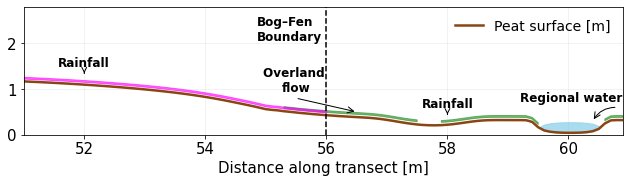

In [4]:
results = (ss, sos, hs, rs, ds)

PF.transect_plot(results, FinalCount, dX, save_path)

#### Figure 2b

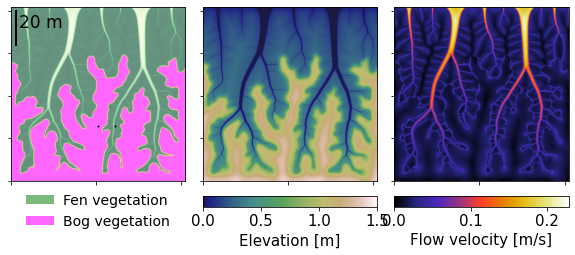

In [14]:
input_data = (ds, rs, sos, ss, ns, FinalCount, Length_X, Length_Y, dX)

PF.model_summary(input_data, save_path)

#### Figure 3a

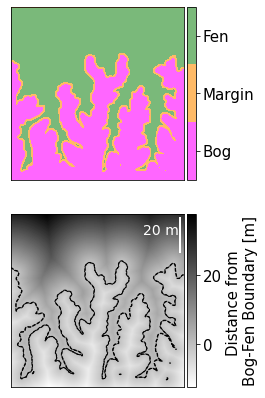

In [6]:
input_data3 = (ds, rs, FinalCount, Length_X, Length_Y, dX)

PF.classes_distance(input_data3, save_path)

#### Figure 3b

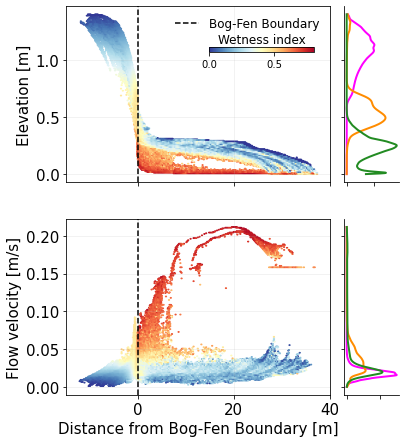

In [12]:
input_data4 = (ds, rs, sos, ss, ns, FinalCount, Length_X, Length_Y, dX, dY)

PF.variables_distance(input_data4, save_path)

#### Sensitivity analysis plots

In [8]:
# fig = plt.figure(figsize=(6, 3))
# plt.plot(Oin_arr, state_mean_ss, marker='o', color='dimgray', label="Inorganic")
# plt.plot(Oin_arr, state_mean_sos, marker='o', color='sienna', label="Organic")
# plt.xlabel("Organic matter input $(O_{in})$") #$k_R$
# plt.ylabel("Mean Sediment \n elevation [m]")
# # plt.legend()
# plt.tight_layout()
# plt.grid(True, alpha=0.2)
# plt.legend(frameon=False)  # clean, frameless legend

# plt.savefig((path.join(save_path,"sediment_comparisons_comp.svg")),dpi = 250)
# plt.show()

In [9]:
# fig = plt.figure(figsize=(6, 3))
# plt.plot(Oin_arr, state_mean_ds, marker='o', color='forestgreen', label="Fen veg.")
# plt.plot(Oin_arr, state_mean_rs, marker='o', color='magenta', label="Bog veg.")
# plt.xlabel("Organic matter input $(O_{in})$")
# plt.ylabel("Mean Vegetation \n biomass [$kg m^{-2}$]")
# # plt.legend()
# plt.tight_layout()
# plt.grid(True, alpha=0.2)
# plt.legend(frameon=False)  # clean, frameless legend

# plt.savefig((path.join(save_path,"vegetation_comparisons_comp.svg")),dpi = 250)
# plt.show()

### Saved arrays for input and analysis

In [10]:
if BuildFen == on:
    np.savez('Fen_%d_v12b' % Grid_Width, 
         u = u,
         v = v, 
         h = h, 
         b = b, 
         s = s, 
         d = d,
         t = t)
else:
    np.savez('BogFenLandscape_%d_v12b' % Grid_Width, 
             Sediment = ss[:,:,FinalCount], 
             Organic = sos[:,:,FinalCount],
             Biomass = ds[:,:,FinalCount], 
             Waterheight = hs[:,:,FinalCount],
             BBiomass = rs[:,:,FinalCount],
             x_vel = us[:,:,FinalCount],
             y_vel = vs[:,:,FinalCount])